Tiene una base de datos preprocesada ya.

In [2]:
import pandas as pd
import lxml
import numpy as np
import json
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn

1. Cargamos el archivo diccionario

In [4]:
# Cargamos el archivo para tener los nombres reales
df_diccionario = pd.read_csv("data_dictionary/BPS_pathologies_gen3.csv")

# Nos aseguramos de que el código BPS sea tratado como texto (string)
# y que tenga ceros a la izquierda (ej: '401' pasa a ser '0401')
df_diccionario['CODE_BPS'] = df_diccionario['CODE_BPS'].astype(str).str.zfill(4)

# Creamos un diccionario rápido de Python para traducir: { 'Código': 'Nombre en inglés' }
traductor_enfermedades = dict(zip(df_diccionario['CODE_BPS'], df_diccionario['BPS_PATHOLOGY']))

2. Cargamos los datos 

In [5]:
ruta_nombre_archivo_json = "data/daae_generated_diabetes_patients_camda_gen3_preprocessed.json"

print("Cargando el archivo JSON... ")
with open(ruta_nombre_archivo_json, 'r') as f:
    datos_json = json.load(f)

registros_limpios = []

print("Procesando los historiales de los pacientes...")
for paciente_id, visitas in datos_json.items():
    # El sexo siempre está en la primera lista/visita
    codigo_sexo = visitas[0][0]
    sexo = "Mujer" if codigo_sexo == "2222" else "Hombre"
    
    # Recorremos el resto de visitas (de la segunda en adelante)
    for visita in visitas[1:]:
        # La edad DEBE empezar por 9 Y tener exactamente 4 caracteres (ej: "9070")
        edad_codigo = [c for c in visita if c.startswith("9") and len(str(c)) == 4]
        
        if edad_codigo:
            # Calculamos la edad real de forma segura
            edad = int(edad_codigo[0]) - 9000
            
            # Las enfermedades serán todo lo que NO sea el código de edad de 4 dígitos
            enfermedades = [c for c in visita if c != edad_codigo[0]]
            
            for enf in enfermedades:
                enf_4digitos = str(enf).zfill(4)
                nombre_enfermedad = traductor_enfermedades.get(enf_4digitos, f"Desconocido ({enf_4digitos})")
                
                registros_limpios.append({
                    "Paciente_ID": paciente_id,
                    "Sexo": sexo,
                    "Edad_Diagnostico": edad, # Ahora la edad será 100% real (entre 0 y 120)
                    "Codigo_Enfermedad": enf_4digitos,
                    "Nombre_Enfermedad": nombre_enfermedad
                })

# Convertimos la lista de registros en un DataFrame gigante de Pandas
df_pacientes = pd.DataFrame(registros_limpios)
print("¡Proceso completado! Tabla 'df_pacientes' creada con éxito.\n")

Cargando el archivo JSON... 
Procesando los historiales de los pacientes...
¡Proceso completado! Tabla 'df_pacientes' creada con éxito.



(Parece que falta un poco de cleaning de la base de datos) -> Comprobarlo 100%, y si es necesario, limpiarla mas
- Que no haya diagnostico de las enfermedades a analizar antes que diabetes
- Que no haya pacientes sin diabetes
- Visitas sin edad o sin sexo (en teoria estas estan quitadas o inferidas)

In [6]:
import pandas as pd

print("="*70)
print("   INFORME DE CALIDAD DE DATOS")
print("="*70)

# ==========================================
# PUNTO 1: Visitas sin edad o sin sexo
# ==========================================
print("\n[1] COMPROBACIÓN DE CAMPOS NULOS O VACÍOS:")
nulos_edad = df_pacientes['Edad_Diagnostico'].isnull().sum()
nulos_sexo = df_pacientes['Sexo'].isnull().sum()

# Comprobamos si hay edades absurdas (como las que vimos de 8000 o menores de 0)
edades_invalidas = ((df_pacientes['Edad_Diagnostico'] < 0) | (df_pacientes['Edad_Diagnostico'] > 120)).sum()

print(f" -> Registros con Edad nula:               {nulos_edad}")
print(f" -> Registros con Sexo nulo:               {nulos_sexo}")
print(f" -> Registros con Edades fuera de rango (0-120 años): {edades_invalidas}")


# ==========================================
# PUNTO 2: Pacientes sin Diabetes (Código 0401)
# ==========================================
print("\n[2] COMPROBACIÓN DE CRITERIO DE INCLUSIÓN (DIABETES):")
total_pacientes_unicos = df_pacientes['Paciente_ID'].nunique()

pacientes_con_diabetes = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0401']['Paciente_ID'].nunique()
pacientes_SIN_diabetes = total_pacientes_unicos - pacientes_con_diabetes

print(f" -> Total de pacientes únicos en el dataset: {total_pacientes_unicos}")
print(f" -> Pacientes que SÍ tienen Diabetes (0401): {pacientes_con_diabetes}")
print(f" -> Pacientes que NO tienen Diabetes (0401): {pacientes_SIN_diabetes} (¡Debería ser 0!)")


# ==========================================
# PUNTO 3: Diagnósticos cronológicamente anteriores a la Diabetes
# ==========================================
print("\n[3] COMPROBACIÓN DE LA LÍNEA TEMPORAL DE COMPLICACIONES:")

# Volvemos a calcular el debut de la diabetes por paciente
df_diab = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0401']
edad_diab_min = df_diab.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Diabetes_Base')

# Cruzamos esta edad base con el resto de los diagnósticos de la tabla general
df_auditoria_temporal = pd.merge(df_pacientes, edad_diab_min, on='Paciente_ID', how='left')

# Calculamos los años de diferencia con respecto a la diabetes
# Si da menor que 0, es que la enfermedad apareció ANTES de la diabetes
df_auditoria_temporal['Anios_Relativos'] = df_auditoria_temporal['Edad_Diagnostico'] - df_auditoria_temporal['Edad_Diabetes_Base']

# Contamos cuántas filas rompen la regla de las 4 complicaciones que encontramos (Riñón, Corazón, Ceguera, Amputacion)
endpoints_codigos = ['1401', '0910', '0703','1999']
df_errores_cronologicos = df_auditoria_temporal[
    (df_auditoria_temporal['Codigo_Enfermedad'].isin(endpoints_codigos)) & 
    (df_auditoria_temporal['Anios_Relativos'] < 0)
]

pacientes_con_error_cronologico = df_errores_cronologicos['Paciente_ID'].nunique()
print(f" -> Registros de complicaciones que ocurren ANTES de la diabetes: {len(df_errores_cronologicos)}")
print(f" -> Pacientes únicos afectados por este error cronológico:     {pacientes_con_error_cronologico}")
print("="*70)

   INFORME DE CALIDAD DE DATOS

[1] COMPROBACIÓN DE CAMPOS NULOS O VACÍOS:
 -> Registros con Edad nula:               0
 -> Registros con Sexo nulo:               0
 -> Registros con Edades fuera de rango (0-120 años): 0

[2] COMPROBACIÓN DE CRITERIO DE INCLUSIÓN (DIABETES):
 -> Total de pacientes únicos en el dataset: 920173
 -> Pacientes que SÍ tienen Diabetes (0401): 899883
 -> Pacientes que NO tienen Diabetes (0401): 20290 (¡Debería ser 0!)

[3] COMPROBACIÓN DE LA LÍNEA TEMPORAL DE COMPLICACIONES:
 -> Registros de complicaciones que ocurren ANTES de la diabetes: 37245
 -> Pacientes únicos afectados por este error cronológico:     35518


Vamos a quitar los pacientes que no la tienen, y que la primera visita de los pacientes sea cuando se diagnostica la diabetes, ya que nuestro objetivo del estudio es ver la relacion de 4 enfermedades despues de ser diagnosticado con diabetes. Tambien, si con la misma edad se diagnostico dos enfermedades, que vaya por ascendencia de codigo (para que siempre diabetes sea la primera en ser diagnosticada)

In [7]:
import pandas as pd

print("Iniciando purga estricta con ordenación por código en empates...")

# =====================================================================
# PASO 1: Filtrar pacientes que SÍ tienen Diabetes (Código 0401)
# =====================================================================
pacientes_diabeticos_validos = df_pacientes[df_pacientes['Codigo_Enfermedad'] == '0401']['Paciente_ID'].unique()
df_filtrado_inclusion = df_pacientes[df_pacientes['Paciente_ID'].isin(pacientes_diabeticos_validos)].copy()


# =====================================================================
# PASO 2: Calcular la Edad de Debut de Diabetes por Paciente
# =====================================================================
df_solo_diab = df_filtrado_inclusion[df_filtrado_inclusion['Codigo_Enfermedad'] == '0401']
edad_debut_diabetes = df_solo_diab.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Debut_Diabetes')


# =====================================================================
# PASO 3: Cruzar, filtrar errores y ORDENAR POR CÓDIGO EN CASO DE EMPATE
# =====================================================================
df_limpieza_temporal = pd.merge(df_filtrado_inclusion, edad_debut_diabetes, on='Paciente_ID', how='left')

# Filtramos para asegurarnos de que ninguna enfermedad ocurra antes de la edad de debut
df_cronologico = df_limpieza_temporal[
    df_limpieza_temporal['Edad_Diagnostico'] >= df_limpieza_temporal['Edad_Debut_Diabetes']
].copy()

# APLICAMOS TU LÓGICA: Ordenamos por Paciente, por Edad y de forma ASCENDENTE por Código
# Al hacer esto, si un paciente tiene código 0401 y 1401 a la misma edad, el 0401 se coloca primero.
df_cronologico = df_cronologico.sort_values(
    by=['Paciente_ID', 'Edad_Diagnostico', 'Codigo_Enfermedad'], 
    ascending=[True, True, True]
).reset_index(drop=True)


# =====================================================================
# PASO 4: Crear la columna de "Años de Evolución" (Para la IA)
# =====================================================================
df_cronologico['Anios_Desde_Diabetes'] = (
    df_cronologico['Edad_Diagnostico'] - df_cronologico['Edad_Debut_Diabetes']
)

# Guardamos el resultado en la variable limpia definitiva
df_pacientes_clean = df_cronologico.drop(columns=['Edad_Debut_Diabetes'])

print("\n" + "="*60)
print("   ¡PROCESO DE LIMPIEZA Y ORDENACIÓN POR CÓDIGO COMPLETADO!")
print("="*60)
print(f"Pacientes finales controlados: {df_pacientes_clean['Paciente_ID'].nunique()}")
print(f"Registros ordenados cronológicamente: {len(df_pacientes_clean)}")
print("="*60)

Iniciando purga estricta con ordenación por código en empates...

   ¡PROCESO DE LIMPIEZA Y ORDENACIÓN POR CÓDIGO COMPLETADO!
Pacientes finales controlados: 899883
Registros ordenados cronológicamente: 3257047


- ANÁLISIS EXPLORATIORIO (con el dataset limpiado)

In [8]:
print("--- MUESTRA DE LA TABLA PROCESADA ---")
print(df_pacientes_clean.head(10))
print("\n" + "="*50 + "\n")

print("Número total de registros procesados:", len(df_pacientes_clean))
print("Número total de pacientes únicos:", df_pacientes_clean['Paciente_ID'].nunique())

df_unique_patients = df_pacientes_clean.drop_duplicates(subset='Paciente_ID')
print("Número total de pacientes únicos (verificado):", len(df_unique_patients))

--- MUESTRA DE LA TABLA PROCESADA ---
  Paciente_ID   Sexo  Edad_Diagnostico Codigo_Enfermedad  \
0           0  Mujer                70              0401   
1           0  Mujer                70              0913   
2           0  Mujer                72              1302   
3           0  Mujer                74              1401   
4           0  Mujer                75              0402   
5           0  Mujer                78              0507   
6           0  Mujer                80              0212   
7           0  Mujer                80              0506   
8           1  Mujer                65              0401   
9           1  Mujer                70              1002   

        Nombre_Enfermedad  Anios_Desde_Diabetes  
0                Diabetes                     0  
1            Hypertension                     0  
2   Arthrosis/spondylosis                     2  
3  Chronic kidney disease                     4  
4         Hyperlipidaemia                     5  
5

In [9]:
# 1. Conteo de Hombres vs Mujeres en tus datos
print("Distribucion de pacientes por sexo:")
print(df_unique_patients['Sexo'].value_counts())
print ("\n")


Distribucion de pacientes por sexo:
Sexo
Hombre    620536
Mujer     279347
Name: count, dtype: int64




Análisis estadístico de nuestra variable numérica: EDAD

In [10]:
resumen_por_sexo = df_unique_patients.groupby('Sexo')['Edad_Diagnostico'].describe()

# 2. Resumen estadístico General (Total)
resumen_total = pd.DataFrame(df_unique_patients['Edad_Diagnostico'].describe()).T
resumen_total.index = ['Total']

# 3. Concatenamos ambas tablas
tabla_final = pd.concat([resumen_por_sexo, resumen_total])

# 4. Ponemos la tabla (redondeos y enteros para el conteo)
tabla_final = tabla_final.round(1)
tabla_final['count'] = tabla_final['count'].astype(int)

print("="*60)
print(" RESUMEN ESTADÍSTICO DE EDAD (POR PACIENTE ÚNICO REAL) ")
print("="*60)
print(tabla_final)
print("\n" + "-"*60 + "\n")


# 5. Calculamos las modas reales por sexo en la población única
# Mostraria las edades de inicio más frecuentes por sexo
print("Edades de inicio más frecuentes por sexo (Modas Reales):")
for sexo in df_unique_patients['Sexo'].unique():
    moda_sexo = df_unique_patients[df_unique_patients['Sexo'] == sexo]['Edad_Diagnostico'].mode()[0]
    if sexo == "Mujer":
        print(f" -> Mujeres: {int(moda_sexo)} años")
    else:
        print(f" -> Hombres: {int(moda_sexo)} años")

 RESUMEN ESTADÍSTICO DE EDAD (POR PACIENTE ÚNICO REAL) 
         count  mean   std  min   25%   50%   75%    max
Hombre  620536  60.3  12.5  0.0  52.0  61.0  69.0  116.0
Mujer   279347  64.5  14.0  0.0  57.0  66.0  74.0  110.0
Total   899883  61.6  13.1  0.0  54.0  62.0  71.0  116.0

------------------------------------------------------------

Edades de inicio más frecuentes por sexo (Modas Reales):
 -> Mujeres: 68 años
 -> Hombres: 60 años


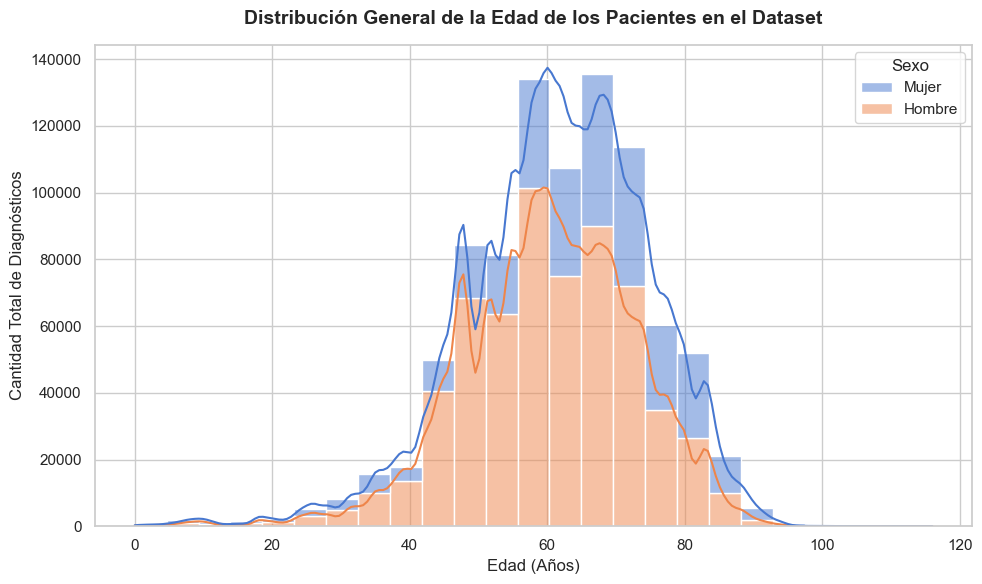

In [11]:
plt.figure(figsize=(10, 6))

# 2. Elegimos un estilo visual limpio y bonito
sns.set_theme(style="whitegrid")

# 3. Creamos el gráfico de distribución de edad
# Usamos 'kde=True' para que dibuje la línea suave de la tendencia
# Usamos 'hue='Sexo'' para que pinte las barras de hombres y mujeres por separado y poder compararlos
sns.histplot(
    data=df_unique_patients, 
    x='Edad_Diagnostico', 
    hue='Sexo', 
    multiple='stack',   # Apila las barras de hombre/mujer para ver también el total combinado
    bins=25,            # Número de barras en las que dividimos la edad
    kde=True,           # Dibuja la curva de densidad suave
    palette='muted'     # Paleta de colores suaves y profesionales
)

# 4. Añadimos las etiquetas de los ejes y el título en español
plt.title('Distribución General de la Edad de los Pacientes en el Dataset', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Cantidad Total de Diagnósticos', fontsize=12)

# 5. Ajustamos los márgenes para que no se corte nada y lo mostramos
plt.tight_layout()
plt.show()



Análisis descriptivo de la variable categórica: Enfermedad

In [12]:
# 2. Las 10 enfermedades más comunes en tu dataset
print("Top 10 enfermedades más comunes:")
top_10 = df_pacientes_clean['Nombre_Enfermedad'].value_counts().head(10)
print(top_10)

Top 10 enfermedades más comunes:
Nombre_Enfermedad
Diabetes                  899883
Hypertension              431377
Hyperlipidaemia           361297
Arthrosis/spondylosis     301078
Anxiety disorder          130214
Heart failure             110657
Obesity                    87019
Atrial fibrillation        77901
COPD                       75598
Chronic kidney disease     68691
Name: count, dtype: int64


In [13]:
#TOP 5 enfermedades más comunes por sexo

for sexo in df_pacientes_clean['Sexo'].unique():
    print(f"\n--- TOP 5: {sexo.upper()} ---")
    df_sexo = df_pacientes_clean[df_pacientes_clean['Sexo'] == sexo]
    total_sexo = df_sexo['Paciente_ID'].nunique()
    
    top_s = df_sexo['Nombre_Enfermedad'].value_counts().head(5).reset_index()
    top_s.columns = ['Enfermedad', 'Pacientes']
    top_s['Prevalencia (%)'] = (top_s['Pacientes'] / total_sexo) * 100
    print(top_s.to_string(index=False))

print("\n" + "-"*60 + "\n")




--- TOP 5: MUJER ---
           Enfermedad  Pacientes  Prevalencia (%)
             Diabetes     279347       100.000000
         Hypertension     135936        48.662058
Arthrosis/spondylosis     121952        43.656098
      Hyperlipidaemia     120293        43.062213
     Anxiety disorder      60326        21.595363

--- TOP 5: HOMBRE ---
           Enfermedad  Pacientes  Prevalencia (%)
             Diabetes     620536       100.000000
         Hypertension     295441        47.610614
      Hyperlipidaemia     241004        38.838037
Arthrosis/spondylosis     179126        28.866335
     Anxiety disorder      69888        11.262521

------------------------------------------------------------



         ESTADÍSTICAS DE COMORBILIDAD
count    899883.000000
mean          3.619412
std           2.336124
min           1.000000
25%           2.000000
50%           3.000000
75%           5.000000
max          28.000000
Name: Codigo_Enfermedad, dtype: float64


/tmp/ipykernel_13767/527355428.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=carga_enfermedades, palette='Blues_r')


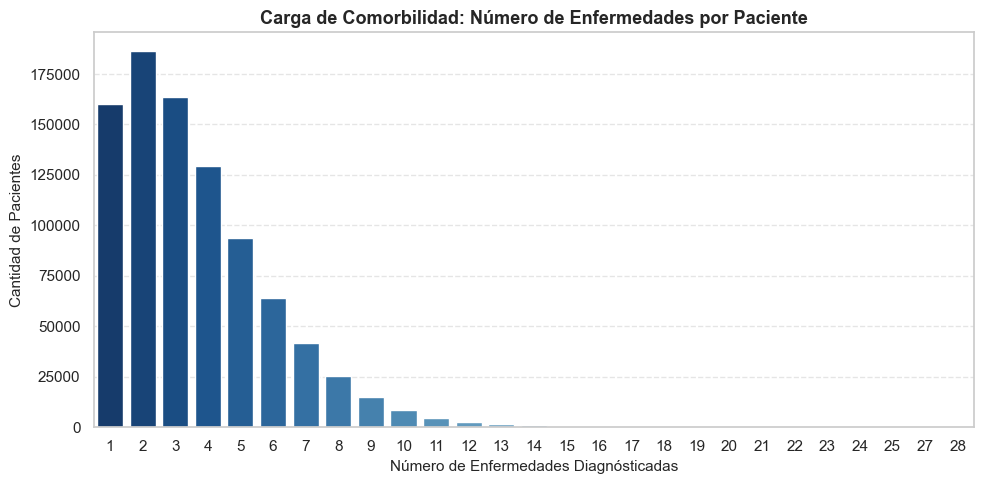

In [14]:
#Análisis de Carga de Comorbilidad (¿Cuántas enfermedades tienen?)
carga_enfermedades = df_pacientes_clean.groupby('Paciente_ID')['Codigo_Enfermedad'].count()

print("="*60)
print("         ESTADÍSTICAS DE COMORBILIDAD")
print("="*60)
print(carga_enfermedades.describe())


# =====================================================================
# VISUALIZACIÓN: Gráfico de barras de la Carga de Comorbilidad
# =====================================================================
plt.figure(figsize=(10, 5))
sns.countplot(x=carga_enfermedades, palette='Blues_r')

plt.title('Carga de Comorbilidad: Número de Enfermedades por Paciente', fontsize=13, fontweight='bold')
plt.xlabel('Número de Enfermedades Diagnósticadas', fontsize=11)
plt.ylabel('Cantidad de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

De media por paciente tienen cuatro enfermedades diagnósticadas

- ANÁLISIS ENDPOINTS

In [15]:
# 1. Definimos los 4 códigos oficiales del challenge
endpoints = {
    "0703": "Retinopatía diabética (Ceguera)",
    "1401": "Enfermedad Renal Crónica (Riñón)",
    "0910": "Cardiopatía Isquémica (Corazón)",
    "1999": "Amputaciones"
}

# 2. Calculamos los totales de referencia de pacientes únicos por sexo
total_pacientes_gen = df_pacientes_clean.groupby('Paciente_ID')['Sexo'].first()
n_hombres = (total_pacientes_gen == 'Hombre').sum()
n_mujeres = (total_pacientes_gen == 'Mujer').sum()
n_total = len(total_pacientes_gen)

print("="*75)
print("   ESTUDIO DE PREVALENCIA DE ENDPOINTS (COMPLICACIONES DE LA DIABETES)")
print("="*75)

# Creamos una lista para guardar los resultados y hacer luego una tabla limpia
resultados_endpoints = []

for codigo, nombre in endpoints.items():
    # Filtramos las filas que tengan esta complicación
    df_complicacion = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == codigo]
    
    # Agrupamos por paciente único para saber el sexo de quienes la sufren
    pacientes_afectados = df_complicacion.groupby('Paciente_ID')['Sexo'].first()
    
    # Contamos por sexo
    casos_hombres = (pacientes_afectados == 'Hombre').sum()
    casos_mujeres = (pacientes_afectados == 'Mujer').sum()
    casos_total = len(pacientes_afectados)
    
    # Calculamos porcentajes reales sobre sus respectivas poblaciones
    pct_hombres = (casos_hombres / n_hombres) * 100 if n_hombres > 0 else 0
    pct_mujeres = (casos_mujeres / n_mujeres) * 100 if n_mujeres > 0 else 0
    pct_total = (casos_total / n_total) * 100 if n_total > 0 else 0
    
    # Guardamos los datos para la tabla
    resultados_endpoints.append({
        "Complicación": nombre,
        "Código": codigo,
        "Casos Hombres": f"{casos_hombres} ({pct_hombres:.2f}%)",
        "Casos Mujeres": f"{casos_mujeres} ({pct_mujeres:.2f}%)",
        "Total General": f"{casos_total} ({pct_total:.2f}%)",
        "Total_Num": casos_total # Guardamos el número puro para el análisis posterior
    })

# 3. Convertimos en DataFrame de Pandas para mostrarlo impecable
df_resultados_endpoints = pd.DataFrame(resultados_endpoints)
print(df_resultados_endpoints.drop(columns=['Total_Num']).to_string(index=False))
print("="*75)

   ESTUDIO DE PREVALENCIA DE ENDPOINTS (COMPLICACIONES DE LA DIABETES)
                    Complicación Código Casos Hombres Casos Mujeres Total General
 Retinopatía diabética (Ceguera)   0703 41644 (6.71%) 26134 (9.36%) 67778 (7.53%)
Enfermedad Renal Crónica (Riñón)   1401 47467 (7.65%) 21224 (7.60%) 68691 (7.63%)
 Cardiopatía Isquémica (Corazón)   0910 43942 (7.08%) 18766 (6.72%) 62708 (6.97%)
                    Amputaciones   1999     0 (0.00%)     0 (0.00%)     0 (0.00%)


Ejemplo: Enfermedad Renal Crónica 


  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD RENAL?
          count  mean  std  min  25%  50%   75%   max
Sexo                                                 
Hombre  47467.0   6.6  5.9  0.0  2.0  6.0  10.0  77.0
Mujer   21224.0   7.7  6.3  0.0  3.0  7.0  12.0  85.0


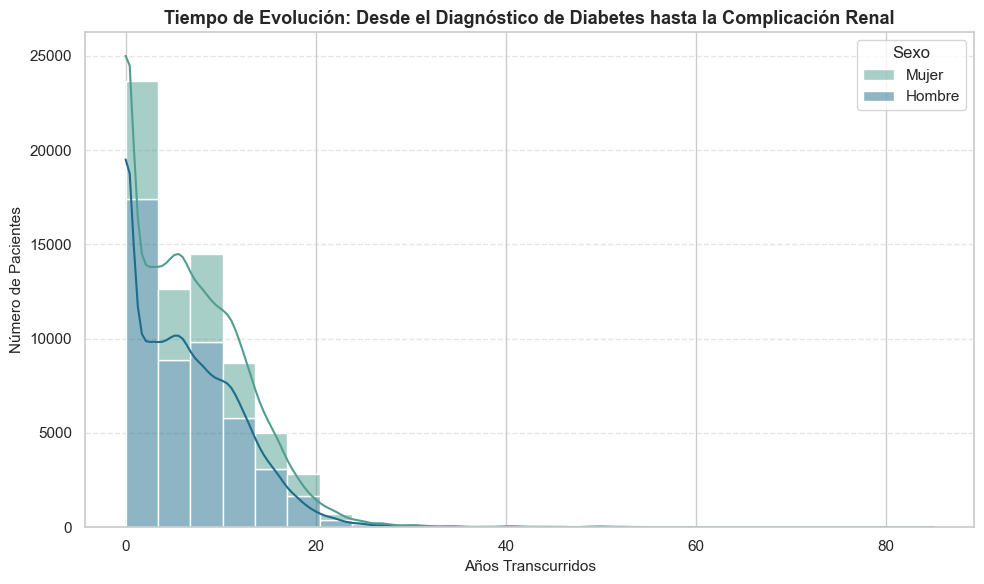

In [16]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la edad de debut de la Diabetes (0401) por paciente
df_diabetes = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '0401']
edad_diabetes = df_diabetes.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Diabetes')

# 2. Obtenemos la edad de aparición del fallo Renal (1401) por paciente
df_rinon = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '1401']
edad_rinon = df_rinon.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Rinon')

# 3. Cruzamos los datos de los pacientes que tienen AMBAS enfermedades
df_temporal = pd.merge(edad_diabetes, edad_rinon, on='Paciente_ID', how='inner')

# Extraemos también el Sexo para poder comparar hombres y mujeres
sexo_pacientes = df_pacientes_clean.groupby('Paciente_ID')['Sexo'].first()
df_temporal = df_temporal.join(sexo_pacientes)

# 4. Calculamos los años que pasan entre un diagnóstico y otro
df_temporal['Anios_Hasta_Complicacion'] = df_temporal['Edad_Rinon'] - df_temporal['Edad_Diabetes']


print("\n" + "="*60)
print("  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD RENAL?")
print("="*60)
resumen_tiempo = df_temporal.groupby('Sexo')['Anios_Hasta_Complicacion'].describe().round(1)
print(resumen_tiempo)
print("="*60)

# Visualizacion de la distribución del tiempo hasta la complicación renal
plt.figure(figsize=(10, 6))

# Pintamos la distribución del tiempo hasta el evento
sns.histplot(
    data=df_temporal, 
    x='Anios_Hasta_Complicacion', 
    hue='Sexo', 
    multiple='stack', 
    kde=True, 
    bins=25,
    palette='crest'
)

plt.title('Tiempo de Evolución: Desde el Diagnóstico de Diabetes hasta la Complicación Renal', fontsize=13, fontweight='bold')
plt.xlabel('Años Transcurridos', fontsize=11)
plt.ylabel('Número de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

A los hombres en riñon les tarda unos ~6.7 años en aparecer la enfermedad, y a las mujeres a los 7.7. 

 Cardiopatía Isquémica (Corazón)


  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?
          count  mean  std  min  25%  50%  75%   max
Sexo                                                
Hombre  43942.0   4.0  4.9  0.0  0.0  2.0  7.0  59.0
Mujer   18766.0   4.5  5.4  0.0  0.0  2.0  8.0  56.0


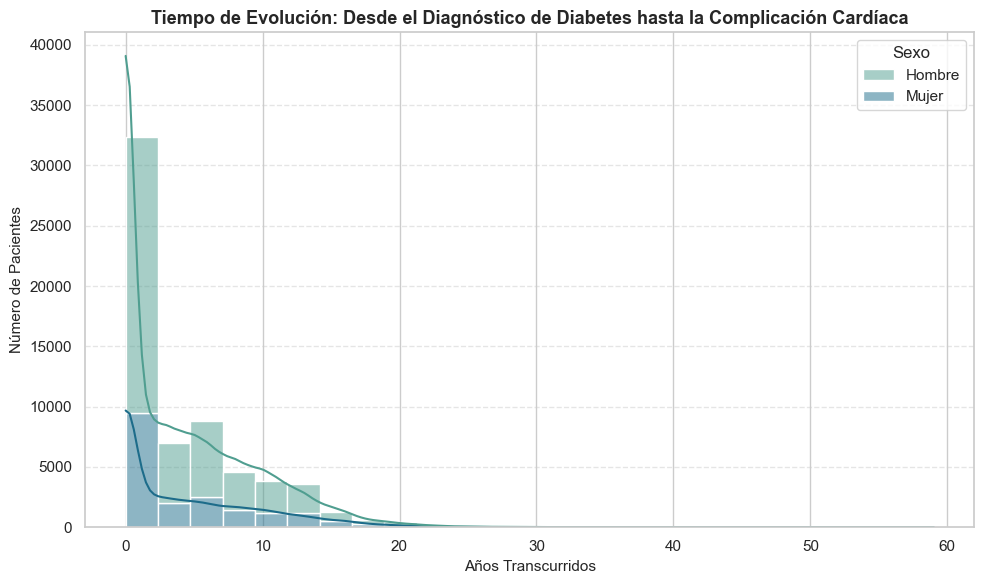

In [17]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la edad de debut de la Diabetes (0401) por paciente
df_diabetes = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '0401']
edad_diabetes = df_diabetes.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Diabetes')

# 2. Obtenemos la edad de aparición del  Cardiopatía Isquémica (Corazón) (0910) por paciente
df_corazon = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '0910']
edad_corazon = df_corazon.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Corazon')

# 3. Cruzamos los datos de los pacientes que tienen AMBAS enfermedades
df_temporal = pd.merge(edad_diabetes, edad_corazon, on='Paciente_ID', how='inner')

# Extraemos también el Sexo para poder comparar hombres y mujeres
sexo_pacientes = df_pacientes_clean.groupby('Paciente_ID')['Sexo'].first()
df_temporal = df_temporal.join(sexo_pacientes)

# 4. Calculamos los años que pasan entre un diagnóstico y otro
df_temporal['Anios_Hasta_Complicacion'] = df_temporal['Edad_Corazon'] - df_temporal['Edad_Diabetes']


print("\n" + "="*60)
print("  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?")
print("="*60)
resumen_tiempo = df_temporal.groupby('Sexo')['Anios_Hasta_Complicacion'].describe().round(1)
print(resumen_tiempo)
print("="*60)

# Visualizacion de la distribución del tiempo hasta la complicación renal
plt.figure(figsize=(10, 6))

# Pintamos la distribución del tiempo hasta el evento
sns.histplot(
    data=df_temporal, 
    x='Anios_Hasta_Complicacion', 
    hue='Sexo', 
    multiple='stack', 
    kde=True, 
    bins=25,
    palette='crest'
)

plt.title('Tiempo de Evolución: Desde el Diagnóstico de Diabetes hasta la Complicación Cardíaca', fontsize=13, fontweight='bold')
plt.xlabel('Años Transcurridos', fontsize=11)
plt.ylabel('Número de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

4-4.5 años. Hombres y mujeres distancia muy similar.

Retinopatía diabética (Ceguera)


  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?
          count  mean  std  min  25%  50%   75%   max
Sexo                                                 
Hombre  41644.0   5.5  5.3  0.0  1.0  4.0   9.0  68.0
Mujer   26134.0   6.2  5.8  0.0  1.0  5.0  10.0  58.0


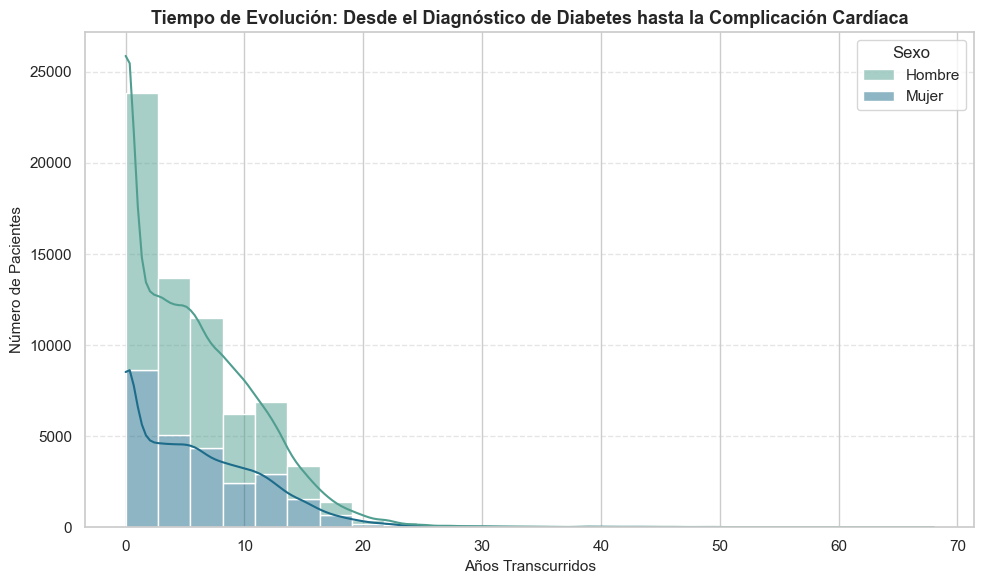

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Obtenemos la edad de debut de la Diabetes (0401) por paciente
df_diabetes = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '0401']
edad_diabetes = df_diabetes.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Diabetes')

# 2. Obtenemos la edad de aparición de la Retinopatía diabética (Ceguera) (0703) por paciente
df_retinopatia = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '0703']
edad_retinopatia = df_retinopatia.groupby('Paciente_ID')['Edad_Diagnostico'].min().rename('Edad_Retinopatia')

# 3. Cruzamos los datos de los pacientes que tienen AMBAS enfermedades
df_temporal = pd.merge(edad_diabetes, edad_retinopatia, on='Paciente_ID', how='inner')

# Extraemos también el Sexo para poder comparar hombres y mujeres
sexo_pacientes = df_pacientes_clean.groupby('Paciente_ID')['Sexo'].first()
df_temporal = df_temporal.join(sexo_pacientes)

# 4. Calculamos los años que pasan entre un diagnóstico y otro
df_temporal['Anios_Hasta_Complicacion'] = df_temporal['Edad_Retinopatia'] - df_temporal['Edad_Diabetes']


print("\n" + "="*60)
print("  ¿CUÁNTOS AÑOS TARDAN EN DESARROLLAR LA ENFERMEDAD?")
print("="*60)
resumen_tiempo = df_temporal.groupby('Sexo')['Anios_Hasta_Complicacion'].describe().round(1)
print(resumen_tiempo)
print("="*60)

# Visualizacion de la distribución del tiempo hasta la complicación renal
plt.figure(figsize=(10, 6))

# Pintamos la distribución del tiempo hasta el evento
sns.histplot(
    data=df_temporal, 
    x='Anios_Hasta_Complicacion', 
    hue='Sexo', 
    multiple='stack', 
    kde=True, 
    bins=25,
    palette='crest'
)

plt.title('Tiempo de Evolución: Desde el Diagnóstico de Diabetes hasta la Complicación Cardíaca', fontsize=13, fontweight='bold')
plt.xlabel('Años Transcurridos', fontsize=11)
plt.ylabel('Número de Pacientes', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

Desde que se diagnostica la diabetes, tarda unos 5.5-6 años en desarrollar ceguera para hombres y mujeres. 

PREDICCION

In [19]:
import pandas as pd
import numpy as np

print("Construyendo matriz con múltiples variables objetivo (Targets)...")

# 1. Identificamos los IDs de los pacientes que sufren cada complicación
pacientes_rinon = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '1401']['Paciente_ID'].unique()
pacientes_corazon = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '0910']['Paciente_ID'].unique()
pacientes_retina = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'] == '0703']['Paciente_ID'].unique()

# 2. Creamos la base de Pacientes Únicos con sus características (X)
df_ml_multi = df_pacientes_clean.groupby('Paciente_ID').agg({
    'Sexo': 'first',
    'Edad_Diagnostico': 'min'  # Edad de debut
}).reset_index()

df_ml_multi.columns = ['Paciente_ID', 'Sexo', 'Edad_Debut']

# Transformamos el Sexo a número (Hombre=1, Mujer=0)
df_ml_multi['Sexo_Hombre'] = np.where(df_ml_multi['Sexo'] == 'Hombre', 1, 0)

# =====================================================================
# CREACIÓN DE LOS TARGETS (0 o 1)
# =====================================================================
df_ml_multi['Target_Rinon'] = np.where(df_ml_multi['Paciente_ID'].isin(pacientes_rinon), 1, 0)
df_ml_multi['Target_Corazon'] = np.where(df_ml_multi['Paciente_ID'].isin(pacientes_corazon), 1, 0)
df_ml_multi['Target_Retina'] = np.where(df_ml_multi['Paciente_ID'].isin(pacientes_retina), 1, 0)

# El Target Conjunto (Riesgo Global): Será 1 si el paciente tiene un 1 en CUALQUIERA de las tres
df_ml_multi['Target_Global'] = np.where(
    (df_ml_multi['Target_Rinon'] == 1) | 
    (df_ml_multi['Target_Corazon'] == 1) | 
    (df_ml_multi['Target_Retina'] == 1), 
    1, 0
)

print("\nMatriz preparada con éxito. Columnas generadas:")
print(df_ml_multi[['Edad_Debut', 'Sexo_Hombre', 'Target_Rinon', 'Target_Corazon', 'Target_Retina', 'Target_Global']].head())

Construyendo matriz con múltiples variables objetivo (Targets)...

Matriz preparada con éxito. Columnas generadas:
   Edad_Debut  Sexo_Hombre  Target_Rinon  Target_Corazon  Target_Retina  \
0          70            0             1               0              0   
1          65            0             0               0              0   
2          61            1             0               0              0   
3          72            1             0               0              0   
4          68            1             0               0              1   

   Target_Global  
0              1  
1              0  
2              0  
3              0  
4              1  


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import HistGradientBoostingClassifier # Algoritmo más potente
from sklearn.metrics import classification_report
import numpy as np

# Mantenemos las mismas X e y
X = df_ml_multi[['Edad_Debut', 'Sexo_Hombre']]
lista_targets = ['Target_Rinon', 'Target_Corazon', 'Target_Retina', 'Target_Global']

print("\nEntrenando con HistGradientBoosting y ajuste de umbral...")

for target in lista_targets:
    print(f"\n" + "="*60)
    print(f" EVALUANDO: {target.upper()} (Umbral optimizado)")
    print("="*60)
    
    y = df_ml_multi[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    
    # Usamos un modelo basado en Boosting que maneja mejor estructuras complejas
    # class_weight='balanced' está soportado de forma nativa en HistGradientBoostingClassifier
    model = HistGradientBoostingClassifier(random_state=42, class_weight='balanced')
    model.fit(X_train, y_train)
    
    # En lugar de usar model.predict(), sacamos las PROBABILIDADES puras (de 0.0 a 1.0)
    probabilidades = model.predict_proba(X_test)[:, 1]
    
    # BAJAMOS EL UMBRAL: Si la probabilidad es mayor al 35% (0.35), lo clasificamos como 1
    # Esto ayuda drásticamente a mejorar el 'recall' de la clase 1
    umbral_medico = 0.35
    y_pred_ajustado = np.where(probabilidades >= umbral_medico, 1, 0)
    
    print(classification_report(y_test, y_pred_ajustado))


Entrenando con HistGradientBoosting y ajuste de umbral...

 EVALUANDO: TARGET_RINON (Umbral optimizado)
              precision    recall  f1-score   support

           0       0.97      0.19      0.32    166239
           1       0.09      0.93      0.16     13738

    accuracy                           0.25    179977
   macro avg       0.53      0.56      0.24    179977
weighted avg       0.90      0.25      0.31    179977


 EVALUANDO: TARGET_CORAZON (Umbral optimizado)
              precision    recall  f1-score   support

           0       0.97      0.09      0.17    167435
           1       0.07      0.96      0.14     12542

    accuracy                           0.15    179977
   macro avg       0.52      0.53      0.15    179977
weighted avg       0.91      0.15      0.16    179977


 EVALUANDO: TARGET_RETINA (Umbral optimizado)
              precision    recall  f1-score   support

           0       0.97      0.10      0.18    166421
           1       0.08      0.97    

Hacer el csv con la matriz de enfermedades en variables binarias:

In [21]:
import pandas as pd
import numpy as np

print("Iniciando la creación de la Matriz de Comorbilidad Completa...")

# =====================================================================
# PASO 1: Filtrar enfermedades irrelevantes o ultra-raras (Opcional pero recomendado)
# =====================================================================
# Contamos cuántos pacientes únicos tienen cada código de enfermedad
conteo_enfermedades = df_pacientes_clean.groupby('Codigo_Enfermedad')['Paciente_ID'].nunique()

# Nos quedamos solo con los códigos que tengan al menos 500 pacientes (evita ruido en el grafo)
codigos_frecuentes = conteo_enfermedades[conteo_enfermedades >= 500].index.tolist()

df_filtrado_grafo = df_pacientes_clean[df_pacientes_clean['Codigo_Enfermedad'].isin(codigos_frecuentes)]


# =====================================================================
# PASO 2: Pivotar la tabla (Transformar filas de enfermedades en columnas binarias)
# =====================================================================
print("Pivotando datos... (Creando columnas 0 y 1 para cada código)")

# pd.crosstab genera una matriz de Paciente_ID x Codigo_Enfermedad con el conteo
matriz_presencia = pd.crosstab(df_filtrado_grafo['Paciente_ID'], df_filtrado_grafo['Nombre_Enfermedad'])

# Como solo nos importa si aparece o no (binario), convertimos cualquier valor > 0 en 1
matriz_binaria = (matriz_presencia > 0).astype(int).reset_index()


# =====================================================================
# PASO 3: Recuperar las variables demográficas básicas (Edad de debut y Sexo)
# =====================================================================
df_demograficos = df_pacientes_clean.groupby('Paciente_ID').agg({
    'Sexo': 'first',
    'Edad_Diagnostico': 'min' # Edad de debut de la diabetes
}).reset_index()

df_demograficos.columns = ['Paciente_ID', 'Sexo', 'Edad_Debut_Diabetes']
df_demograficos['Sexo_Hombre'] = np.where(df_demograficos['Sexo'] == 'Hombre', 1, 0)
df_demograficos = df_demograficos.drop(columns=['Sexo'])


# =====================================================================
# PASO 4: Unir todo en la Matriz Final para el TFM
# =====================================================================
df_matriz_comorbilidad = pd.merge(df_demograficos, matriz_binaria, on='Paciente_ID', how='left')

# Si algún paciente no quedó en la matriz binaria por el filtro de los 500, rellenamos con 0
df_matriz_comorbilidad = df_matriz_comorbilidad.fillna(0)

# Aseguramos que los códigos sigan siendo enteros/binarios tras el merge
columnas_enfermedades = [col for col in df_matriz_comorbilidad.columns if col not in ['Paciente_ID', 'Edad_Debut_Diabetes', 'Sexo_Hombre']]
df_matriz_comorbilidad[columnas_enfermedades] = df_matriz_comorbilidad[columnas_enfermedades].astype(int)

print("\n" + "="*70)
print("       ¡MATRIZ DE COMORBILIDAD GENERADA CON ÉXITO!")
print("="*70)
print(f"Número total de Pacientes (Filas):      {df_matriz_comorbilidad.shape[0]:,}")
print(f"Número de Variables / Enfermedades (Columnas): {df_matriz_comorbilidad.shape[1]}")
print("="*70)
print("\nVistazo a las primeras columnas:")
print(df_matriz_comorbilidad.iloc[:5, :8]) # Muestra los primeros 5 pacientes y 8 columnas

Iniciando la creación de la Matriz de Comorbilidad Completa...
Pivotando datos... (Creando columnas 0 y 1 para cada código)

       ¡MATRIZ DE COMORBILIDAD GENERADA CON ÉXITO!
Número total de Pacientes (Filas):      899,883
Número de Variables / Enfermedades (Columnas): 79

Vistazo a las primeras columnas:
  Paciente_ID  Edad_Debut_Diabetes  Sexo_Hombre  Acquired heart diseases  \
0           0                   70            0                        0   
1           1                   65            0                        0   
2          10                   61            1                        0   
3        1000                   72            1                        0   
4       10000                   68            1                        0   

   Age-related macular degeneration  Alcohol dependence  Anxiety disorder  \
0                                 0                   0                 1   
1                                 0                   0                 0   
2   

In [23]:
# Definimos el nombre del archivo CSV
nombre_archivo_csv = "matriz_comorbilidad_clean.csv"
X_matriz = df_matriz_comorbilidad.drop(columns=['Paciente_ID'])

print(f"Exportando la matriz a '{nombre_archivo_csv}'... (Esto puede tardar un poquito debido al volumen de datos)")

# Exportamos a CSV
X_matriz.to_csv(nombre_archivo_csv, index=False)

print("\n" + "="*60)
print(f" ¡ARCHIVO GUARDADO! Se ha creado con éxito: {nombre_archivo_csv}")
print("="*60)

Exportando la matriz a 'matriz_comorbilidad_clean.csv'... (Esto puede tardar un poquito debido al volumen de datos)

 ¡ARCHIVO GUARDADO! Se ha creado con éxito: matriz_comorbilidad_clean.csv
